In [23]:
import earthaccess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker,colors
import matplotlib.style as style
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from scipy import stats
import math
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime,date, timedelta
import datetime as dt 
import cmocean as cmoc
import cmocean.cm as cmo
from erddapy import ERDDAP
import time
import requests
from scipy import stats, odr
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import re
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
import os
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import ast
import matplotlib.gridspec as gridspec
import hvplot.xarray
#import holoviews as hv
import hvplot.pandas
import geoviews as gv
from bokeh.models import HoverTool
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
#import contextily as ctx
import xarray.ufuncs as xu
import matplotlib.ticker as mticker
import cblind as cblind
from datetime import date, time, datetime
import seaborn as sns

In [24]:
df1 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\PACE fish-Hackweek\Hypoxia_project\Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.xlsx')
df1['datetime'] = pd.to_datetime(df1['DATE'].astype(str) + ' ' + df1['TIME'].astype(str))
rrs_cols1 = [c for c in df1.columns if 'PRrs' in c]
df1=df1[['datetime','longitude', 'latitude', 'oxygen']+rrs_cols1]
df1['source']='NOAA Hypoxia'

#add in LSU data and reformat to match noaa to concat 
df2 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\PACE fish-Hackweek\Hypoxia_project\Unique_PACE_matchups_LSU_Hypoxia_2024_2025.xlsx')
df2['datetime'] = pd.to_datetime(df2['lsu_Date'].astype(str) + ' ' + df2['lsu_Time.CTD.Cast.began..UTC.'].astype(str))
rrs_cols2 = [c for c in df2.columns if 'PRrs' in c]
df2 = df2.rename(columns={"lsu_Corrected.DO..mg.L.": "oxygen"}).reset_index(drop=True)
df2=df2[['datetime','longitude', 'latitude', 'oxygen']+rrs_cols2]
df2['source']='LSU'

df = pd.concat([df1, df2], axis=0).reset_index(drop=True)

Text(0.5, 1.0, 'Station Locations')

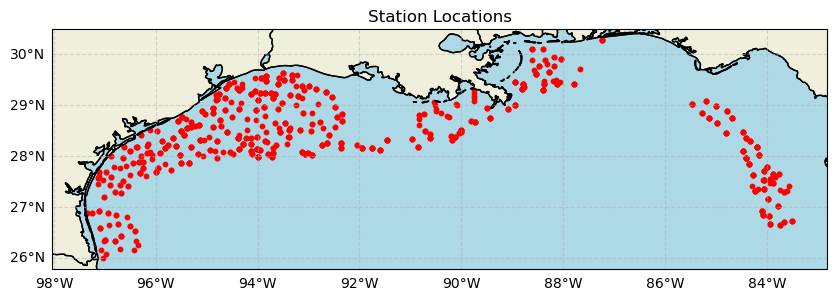

In [25]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES)
ax.scatter(df['longitude'], df['latitude'], color='red', s=10, marker='o')
#for index, row in df.iterrows():
#    ax.text(row['longitude'],  row['latitude'], str(row['STATION']), transform=ccrs.PlateCarree(), fontsize=5,fontweight='bold', color='black', zorder=6) 
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax.set_title('Station Locations')

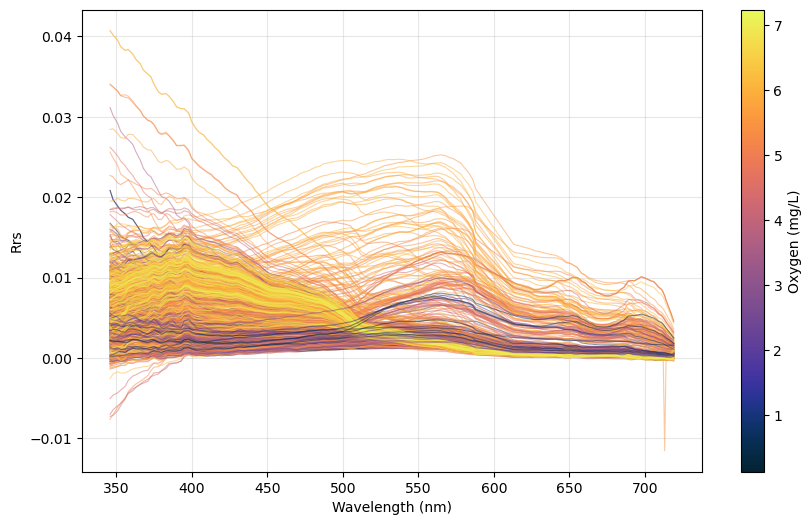

In [26]:
rrs_cols = [c for c in df.columns if 'PRrs' in c]
x_vals = [int(c.replace('PRrs', '')) for c in rrs_cols]

norm = mcolors.Normalize(vmin=df['oxygen'].min(), vmax=df['oxygen'].max())
cmap =cmo.thermal 
fig, ax = plt.subplots(figsize=(10, 6))
for index, row in df.iterrows():
    color = cmap(norm(row['oxygen']))
    ax.plot(x_vals, row[rrs_cols], color=color, alpha=0.5, linewidth=0.8)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Oxygen (mg/L)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Rrs')
ax.grid(True, alpha=0.3)


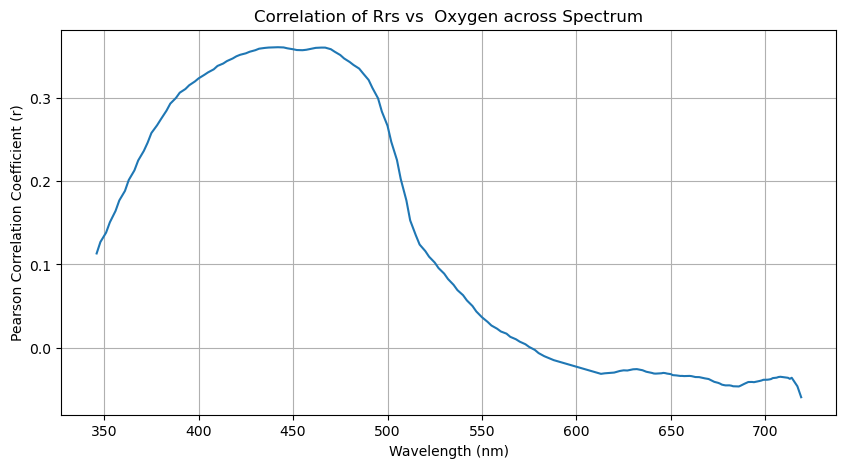

In [27]:
correlations = df[rrs_cols].corrwith(df['oxygen']) #correlation between all rrs rows and oxygen row? 
plt.figure(figsize=(10, 5))
plt.plot(x_vals, correlations)
plt.title('Correlation of Rrs vs  Oxygen across Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Pearson Correlation Coefficient (r)')
plt.grid(True)

#peak correlation 
max_corr = correlations.abs().idxmax()
max_val = correlations[max_corr]
max_wave = max_corr.replace('PRrs', '')

In [28]:
#actually, lets seperate by hypoxia vs not hypoxia 
df_h = df[df['oxygen']<3] #rows of hypoxia
df_nh= df[df['oxygen']>=3] #rows of no hypoxia

Text(0.5, 1.0, 'non-hypoxia points')

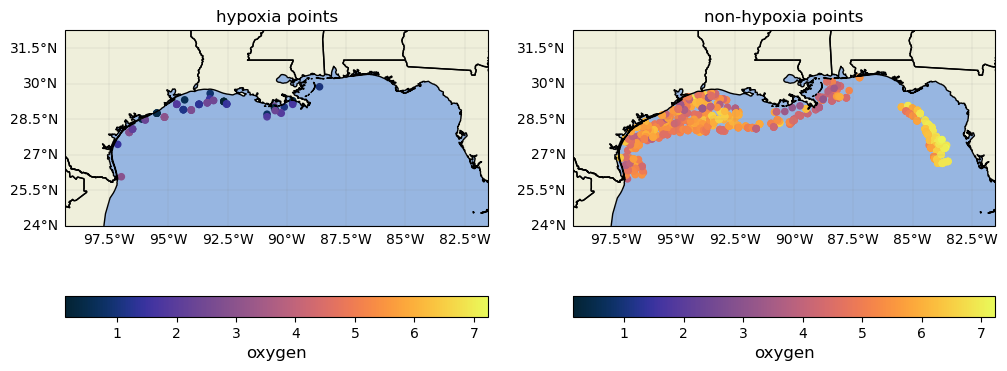

In [29]:
fig=plt.figure(figsize=(12, 9))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.BORDERS)
axs1.add_feature(cfeature.STATES)
im=axs1.scatter(df_h.longitude,df_h.latitude,c=df_h.oxygen,cmap=cmo.thermal,s=20,vmin=min(df.oxygen), vmax=max(df.oxygen))
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.5,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs1.set_ylim(min(df.latitude)-2,max(df.latitude)+2)
axs1.set_xlim(min(df.longitude)-2,max(df.longitude)+2)
cb=fig.colorbar(im,ax=axs1,orientation='horizontal',pad=0.1)
cb.set_label('oxygen',fontsize=12)
axs1.set_title("hypoxia points") 

axs2=fig.add_subplot(1,2,2,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.BORDERS)
axs2.add_feature(cfeature.STATES)
im=axs2.scatter(df_nh.longitude,df_nh.latitude,c=df_nh.oxygen,cmap=cmo.thermal,s=20,vmin=min(df.oxygen), vmax=max(df.oxygen))
gl=axs2.gridlines(linewidth=0.2,color='grey',alpha=0.5,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs2.set_ylim(min(df.latitude)-2,max(df.latitude)+2)
axs2.set_xlim(min(df.longitude)-2,max(df.longitude)+2)
cb=fig.colorbar(im,ax=axs2,orientation='horizontal',pad=0.1)
cb.set_label('oxygen',fontsize=12)
axs2.set_title("non-hypoxia points") 


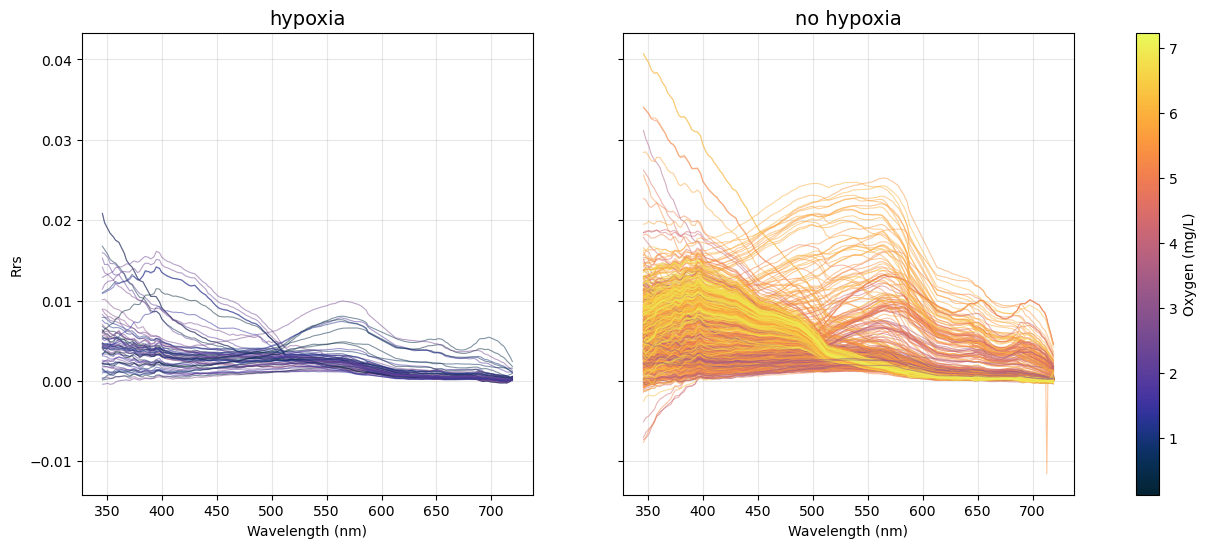

In [30]:
#need to transform columns so that wavelength is in the rows 
rrs_cols = [c for c in df.columns if 'PRrs' in c]
x_vals = [int(c.replace('PRrs', '')) for c in rrs_cols]

norm = mcolors.Normalize(vmin=df['oxygen'].min(), vmax=df['oxygen'].max())
cmap = cmo.thermal
dfs = [df_h, df_nh]
titles = ["hypoxia", "no hypoxia"] # Change these titles as needed

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, df, title in zip(axes, dfs, titles):
    for index, row in df.iterrows():
        color = cmap(norm(row['oxygen']))
        ax.plot(x_vals, row[rrs_cols], color=color, alpha=0.5, linewidth=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Wavelength (nm)')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Rrs')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), label='Oxygen (mg/L)')
plt.show()

# from 1/28

In [31]:
df1 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\PACE fish-Hackweek\Hypoxia_project\Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.xlsx')
df1['datetime'] = pd.to_datetime(df1['DATE'].astype(str) + ' ' + df1['TIME'].astype(str))
rrs_cols1 = [c for c in df1.columns if 'PRrs' in c]
df1=df1[['datetime','longitude', 'latitude', 'oxygen']+rrs_cols1]
df1['source']='NOAA Hypoxia'

#add in LSU data and reformat to match noaa to concat 
df2 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\PACE fish-Hackweek\Hypoxia_project\Unique_PACE_matchups_LSU_Hypoxia_2024_2025.xlsx')
df2['datetime'] = pd.to_datetime(df2['lsu_Date'].astype(str) + ' ' + df2['lsu_Time.CTD.Cast.began..UTC.'].astype(str))
rrs_cols2 = [c for c in df2.columns if 'PRrs' in c]
df2 = df2.rename(columns={"lsu_Corrected.DO..mg.L.": "oxygen"}).reset_index(drop=True)
df2=df2[['datetime','longitude', 'latitude', 'oxygen']+rrs_cols2]
df2['source']='LSU'

df = pd.concat([df1, df2], axis=0).reset_index(drop=True)

In [32]:
#first, take out bad wavelengths (from 590 - 610 and below 400) 
rrs_cols = [c for c in df.columns if 'PRrs' in c]
cols_to_drop = []
for col in rrs_cols: #loop thru each column 
    wavelength = int(col.replace('PRrs', '')) #gather just the value
    if wavelength < 400: #somehow the range from 590-610 is already removed? which explains the line
        cols_to_drop.append(col)
df_new = df.drop(columns=cols_to_drop)

In [33]:
df_h = df_new[df_new['oxygen']<3] #rows of hypoxia
df_nh= df_new[df_new['oxygen']>=3] #rows of no hypoxia


df_h24 = df_h[df_h['datetime'].dt.year == 2024] #hypoxia in 2024
df_h25 = df_h[df_h['datetime'].dt.year == 2025] #hypoxia in 2025 

df_nh24= df_nh[df_nh['datetime'].dt.year == 2024] #no hypoxia 2024
df_nh25= df_nh[df_nh['datetime'].dt.year == 2025]#no hypoxia 2025 

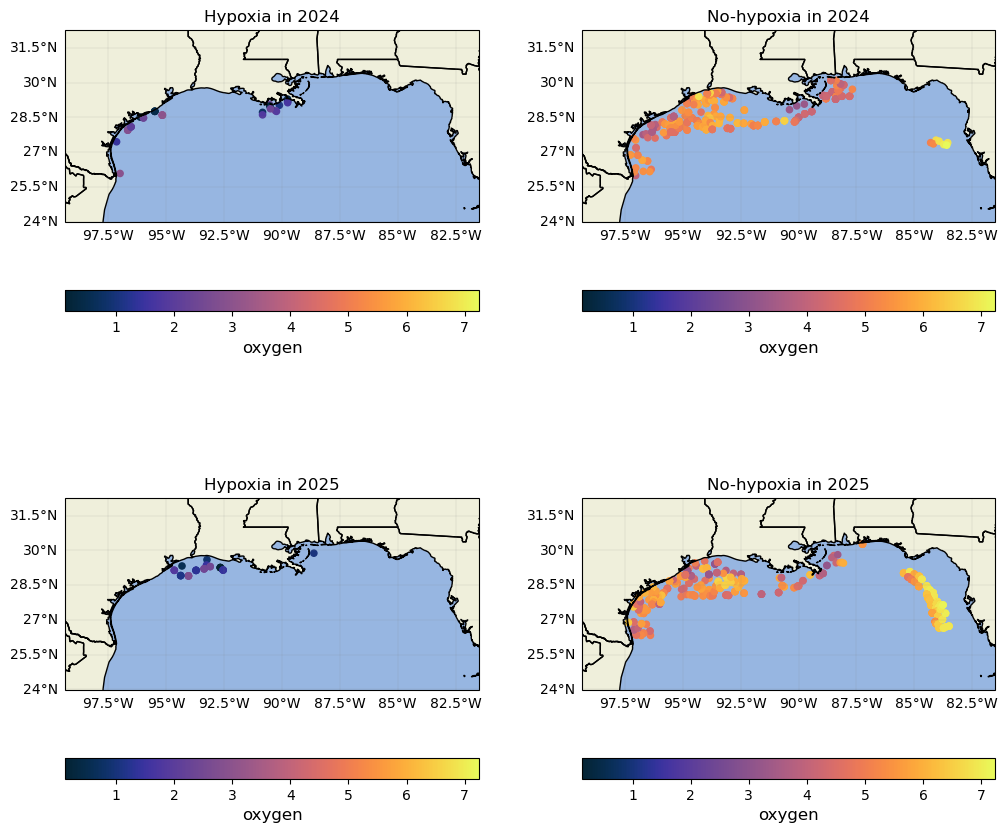

In [34]:

fig=plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 2) # Creates a 2x2 grid
axs1=fig.add_subplot(gs[0, 0],projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.BORDERS)
axs1.add_feature(cfeature.STATES)
im=axs1.scatter(df_h24.longitude,df_h24.latitude,c=df_h24.oxygen,cmap=cmo.thermal,s=20,vmin=min(df.oxygen), vmax=max(df.oxygen))
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.5,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs1.set_ylim(min(df.latitude)-2,max(df.latitude)+2)
axs1.set_xlim(min(df.longitude)-2,max(df.longitude)+2)
cb=fig.colorbar(im,ax=axs1,orientation='horizontal')
cb.set_label('oxygen',fontsize=12)
axs1.set_title("Hypoxia in 2024") 

axs2=fig.add_subplot(gs[0, 1],projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.BORDERS)
axs2.add_feature(cfeature.STATES)
im=axs2.scatter(df_nh24.longitude,df_nh24.latitude,c=df_nh24.oxygen,cmap=cmo.thermal,s=20,vmin=min(df.oxygen), vmax=max(df.oxygen))
gl=axs2.gridlines(linewidth=0.2,color='grey',alpha=0.5,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs2.set_ylim(min(df.latitude)-2,max(df.latitude)+2)
axs2.set_xlim(min(df.longitude)-2,max(df.longitude)+2)
cb=fig.colorbar(im,ax=axs2,orientation='horizontal')
cb.set_label('oxygen',fontsize=12)
axs2.set_title("No-hypoxia in 2024") 

axs3=fig.add_subplot(gs[1, 0],projection= cartopy.crs.PlateCarree())
axs3.add_feature(cfeature.LAND)
axs3.add_feature(cfeature.OCEAN)
axs3.add_feature(cfeature.BORDERS)
axs3.add_feature(cfeature.STATES)
im=axs3.scatter(df_h25.longitude,df_h25.latitude,c=df_h25.oxygen,cmap=cmo.thermal,s=20,vmin=min(df.oxygen), vmax=max(df.oxygen))
gl=axs3.gridlines(linewidth=0.2,color='grey',alpha=0.5,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs3.set_ylim(min(df.latitude)-2,max(df.latitude)+2)
axs3.set_xlim(min(df.longitude)-2,max(df.longitude)+2)
cb=fig.colorbar(im,ax=axs3,orientation='horizontal')
cb.set_label('oxygen',fontsize=12)
axs3.set_title('Hypoxia in 2025') 

axs4=fig.add_subplot(gs[1, 1],projection= cartopy.crs.PlateCarree())
axs4.add_feature(cfeature.LAND)
axs4.add_feature(cfeature.OCEAN)
axs4.add_feature(cfeature.BORDERS)
axs4.add_feature(cfeature.STATES)
im=axs4.scatter(df_nh25.longitude,df_nh25.latitude,c=df_nh25.oxygen,cmap=cmo.thermal,s=20,vmin=min(df.oxygen), vmax=max(df.oxygen))
gl=axs4.gridlines(linewidth=0.2,color='grey',alpha=0.5,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs4.set_ylim(min(df.latitude)-2,max(df.latitude)+2)
axs4.set_xlim(min(df.longitude)-2,max(df.longitude)+2)
cb=fig.colorbar(im,ax=axs4,orientation='horizontal')
cb.set_label('oxygen',fontsize=12)
axs4.set_title('No-hypoxia in 2025') 

gs.update(wspace=0.25, hspace=0.025)


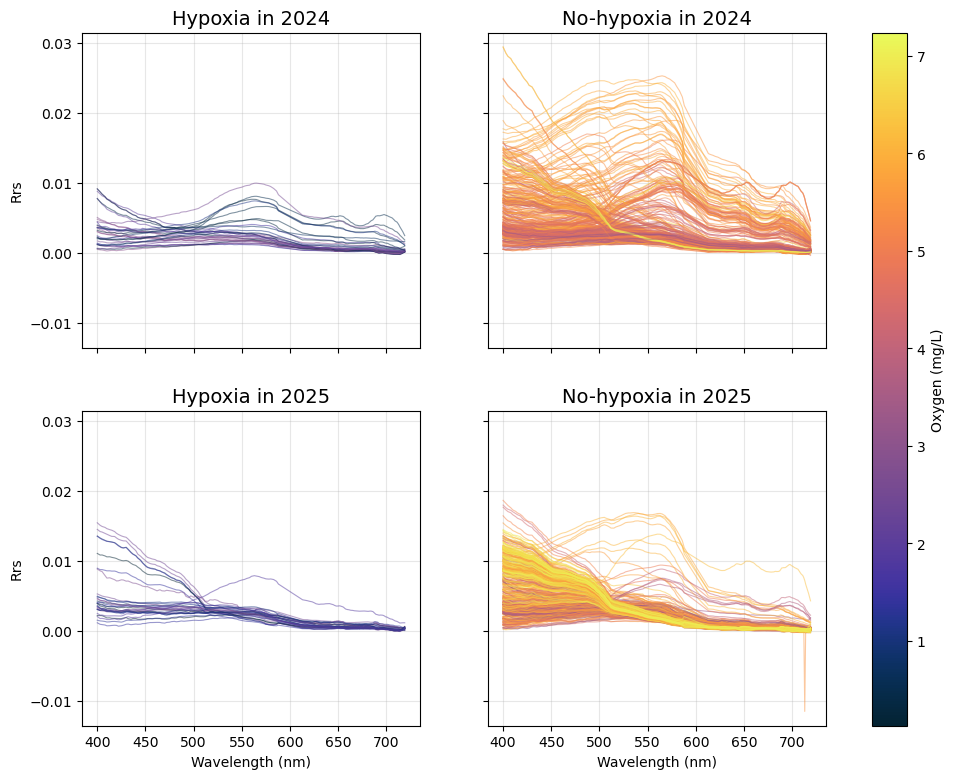

In [35]:
#need to transform columns so that wavelength is in the rows 
rrs_cols = [c for c in df_new.columns if 'PRrs' in c]
x_vals = [int(c.replace('PRrs', '')) for c in rrs_cols]

norm = mcolors.Normalize(vmin=df_new['oxygen'].min(), vmax=df_new['oxygen'].max())
cmap = cmo.thermal
dfs = [df_h24,df_nh24,df_h25, df_nh25]
titles = ["Hypoxia in 2024", "No-hypoxia in 2024",'Hypoxia in 2025','No-hypoxia in 2025'] # Change these titles as needed

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True, sharex=True)
for ax, df, title in zip(axes.flatten(), dfs, titles):
    for index, row in df.iterrows():
        color = cmap(norm(row['oxygen']))
        ax.plot(x_vals, row[rrs_cols], color=color, alpha=0.5, linewidth=0.8)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Rrs')
axes[1, 0].set_ylabel('Rrs')
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 1].set_xlabel('Wavelength (nm)')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), label='Oxygen (mg/L)')

#plt.tight_layout()

In [36]:
#second derivatie of rrs
#need to calculate avw? maybe not? 

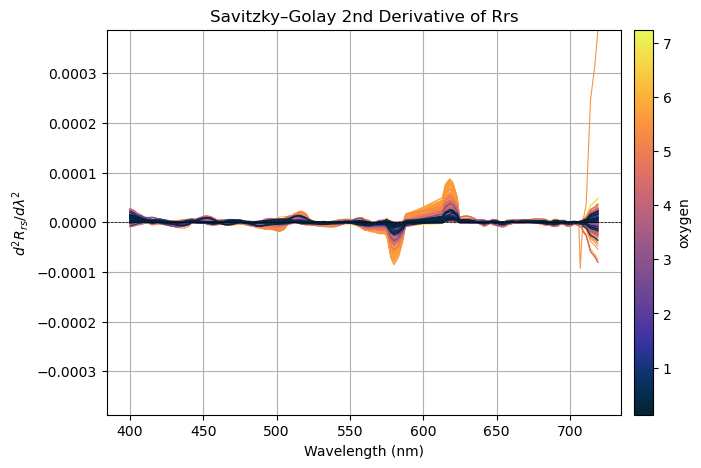

In [37]:
#second derivatie of rrs
sorted_df1 = df_new.sort_values(by='oxygen',ascending=False)

from scipy.signal import savgol_filter
window = 11      # must be odd, tweak as needed
polyorder = 3

#cmap = plt.get_cmap("jet")
cmap = cmo.thermal
norm = colors.Normalize(vmin=min(sorted_df1['oxygen']), vmax=max(sorted_df1['oxygen'])) #already have
fig, ax = plt.subplots(figsize=(8, 5))
ymin, ymax = np.inf, -np.inf
dlam = np.mean(np.diff(x_vals))

rrs_sel = sorted_df1[rrs_cols]
#for spectrum, oxy_val in rrs_sel.values: #per row in the rrs columns 
for spectrum, oxy_val in zip(rrs_sel.values, sorted_df1['oxygen'].values):
    # Savitzky–Golay 2nd derivative
    spec_sg2 = savgol_filter(spectrum, window_length=window, polyorder=polyorder, deriv=2, delta=dlam)
    ymin = min(ymin, np.nanmin(spec_sg2))
    ymax = max(ymax, np.nanmax(spec_sg2))
    color = cmap(norm(oxy_val)) #might be able to just replace this w spectrum? 
    ax.plot(x_vals, spec_sg2, color=color, linewidth=0.8)
    #ax.plot(x_vals, spec_sg2, linewidth=0.8)


ax.set_title("Savitzky–Golay 2nd Derivative of Rrs")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"$d^2 R_{rs} / d\lambda^2$")
ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
# Symmetric limits help derivatives
lim = max(abs(ymin), abs(ymax))
ax.set_ylim(-lim, lim)
ax.grid(True) 

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("oxygen")

plt.show()
 #if this doesn't work, might need to use norm of wavelengths not of oxygen?


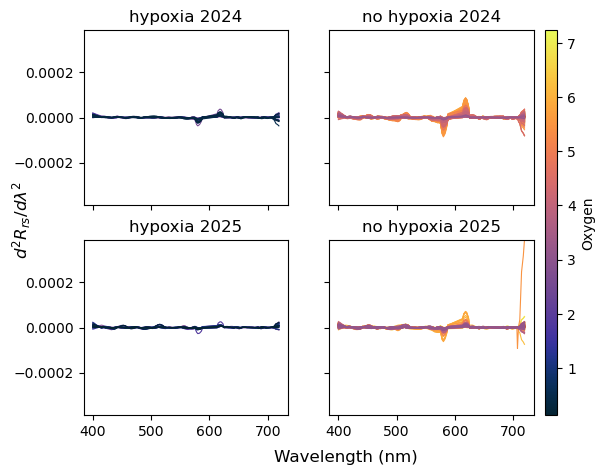

In [38]:
#now seperate into groups
dfs = [df_h24,df_nh24,df_h25, df_nh25]
titles = ["hypoxia 2024", "no hypoxia 2024",'hypoxia 2025','no hypoxia 2025'] # Change these titles as needed

window = 11 
polyorder = 3
dlam = np.mean(np.diff(x_vals))

cmap = cmo.thermal
norm = colors.Normalize(vmin=min(df_new['oxygen']), vmax=max(df_new['oxygen'])) #already have
fig, axes = plt.subplots(2, 2, figsize=(7, 5), sharex=True, sharey=True)
axes_flat = axes.flatten() 
#rrs_sel = df_new[rrs_cols]
ymin, ymax = np.inf, -np.inf


for df, title, ax in zip(dfs, titles, axes_flat):
    sorted_df = df.sort_values(by='oxygen', ascending=False)
    rrs_sel = sorted_df[rrs_cols]
    for spectrum, oxy_val in zip(rrs_sel.values, sorted_df['oxygen'].values):
        # Savitzky–Golay 2nd derivative
        spec_sg2 = savgol_filter(spectrum, window_length=window, polyorder=polyorder, deriv=2, delta=dlam)
        ymin = min(ymin, np.nanmin(spec_sg2))
        ymax = max(ymax, np.nanmax(spec_sg2))
        color = cmap(norm(oxy_val))
        ax.plot(x_vals, spec_sg2, color=color, linewidth=0.8)
    ax.set_title(title)
    #ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
    lim = max(abs(ymin), abs(ymax))
    ax.set_ylim(-lim, lim)

for ax in axes.flat:
    ax.label_outer()
fig.supxlabel("Wavelength (nm)")
fig.supylabel(r"$d^2 R_{rs} / d\lambda^2$")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02, aspect=30)
cbar.set_label("Oxygen")
plt.show()


Text(0.5, 0.98, 'Savitzky–Golay 2nd Derivative of Rrs')

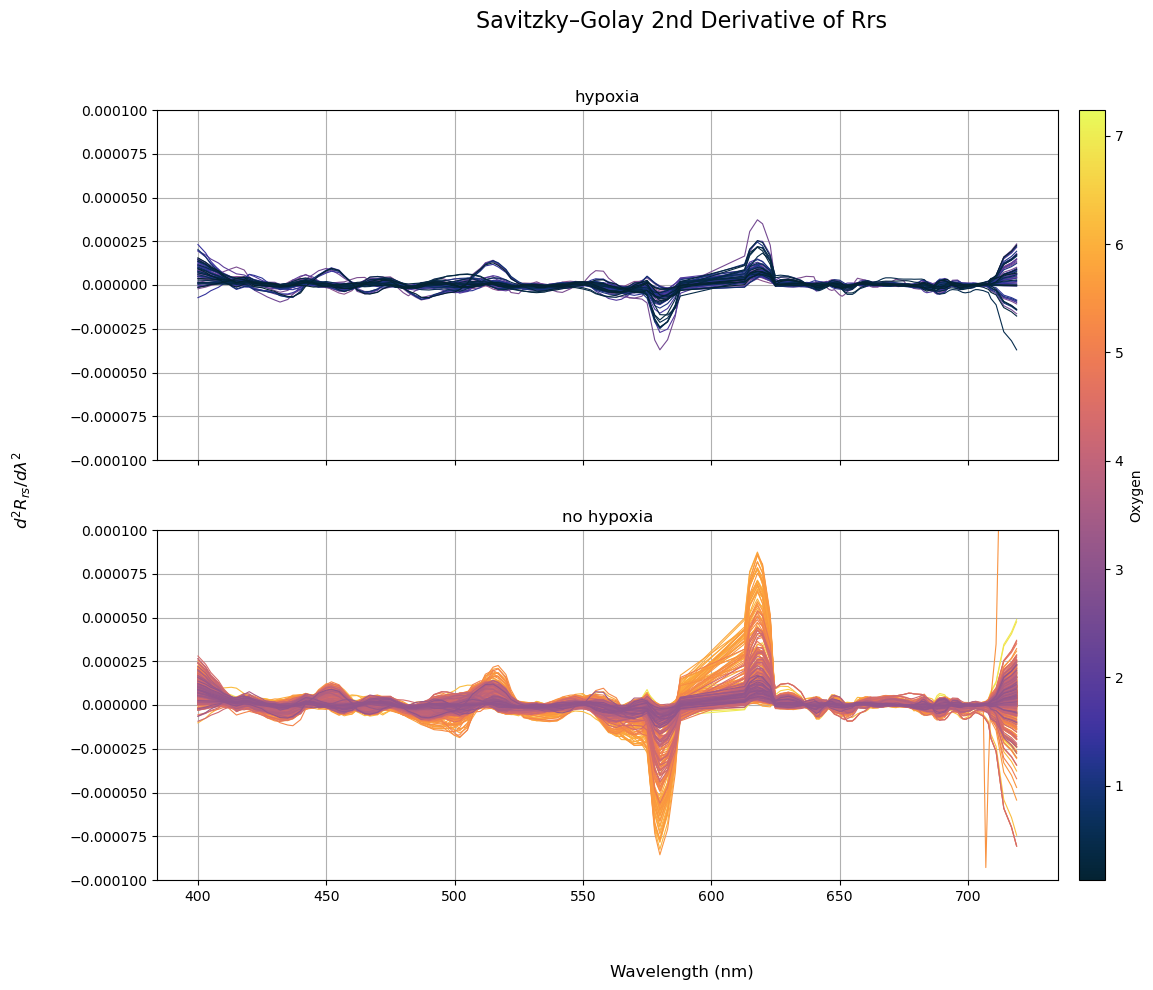

In [39]:
#now seperate into groups
dfs = [df_h,df_nh]
titles = ["hypoxia", "no hypoxia" ] # Change these titles as needed

window = 11 
polyorder = 3
dlam = np.mean(np.diff(x_vals))

cmap = cmo.thermal
norm = colors.Normalize(vmin=min(sorted_df1['oxygen']), vmax=max(sorted_df1['oxygen']))
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)
axes_flat = axes.flatten() 
ymin, ymax = np.inf, -np.inf

for df, title, ax in zip(dfs, titles, axes_flat):
    sorted_df = df.sort_values(by='oxygen', ascending=False)
    rrs_sel = sorted_df[rrs_cols]
    for spectrum, oxy_val in zip(rrs_sel.values, sorted_df['oxygen'].values):
        # Savitzky–Golay 2nd derivative
        spec_sg2 = savgol_filter(spectrum, window_length=window, polyorder=polyorder, deriv=2, delta=dlam)
        ymin = min(ymin, np.nanmin(spec_sg2))
        ymax = max(ymax, np.nanmax(spec_sg2))
        color = cmap(norm(oxy_val))
        ax.plot(x_vals, spec_sg2, color=color, linewidth=0.8)
    ax.set_title(title)
    #ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
    lim = max(abs(ymin), abs(ymax))
    ax.set_ylim(-0.0001, 0.0001)
    ax.grid(True) 
    
#for ax in axes.flat:
#    ax.label_outer()
fig.supxlabel("Wavelength (nm)")
fig.supylabel(r"$d^2 R_{rs} / d\lambda^2$")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02, aspect=30)
cbar.set_label("Oxygen")
fig.suptitle('Savitzky–Golay 2nd Derivative of Rrs', fontsize=16) # Call suptitle on the figure object


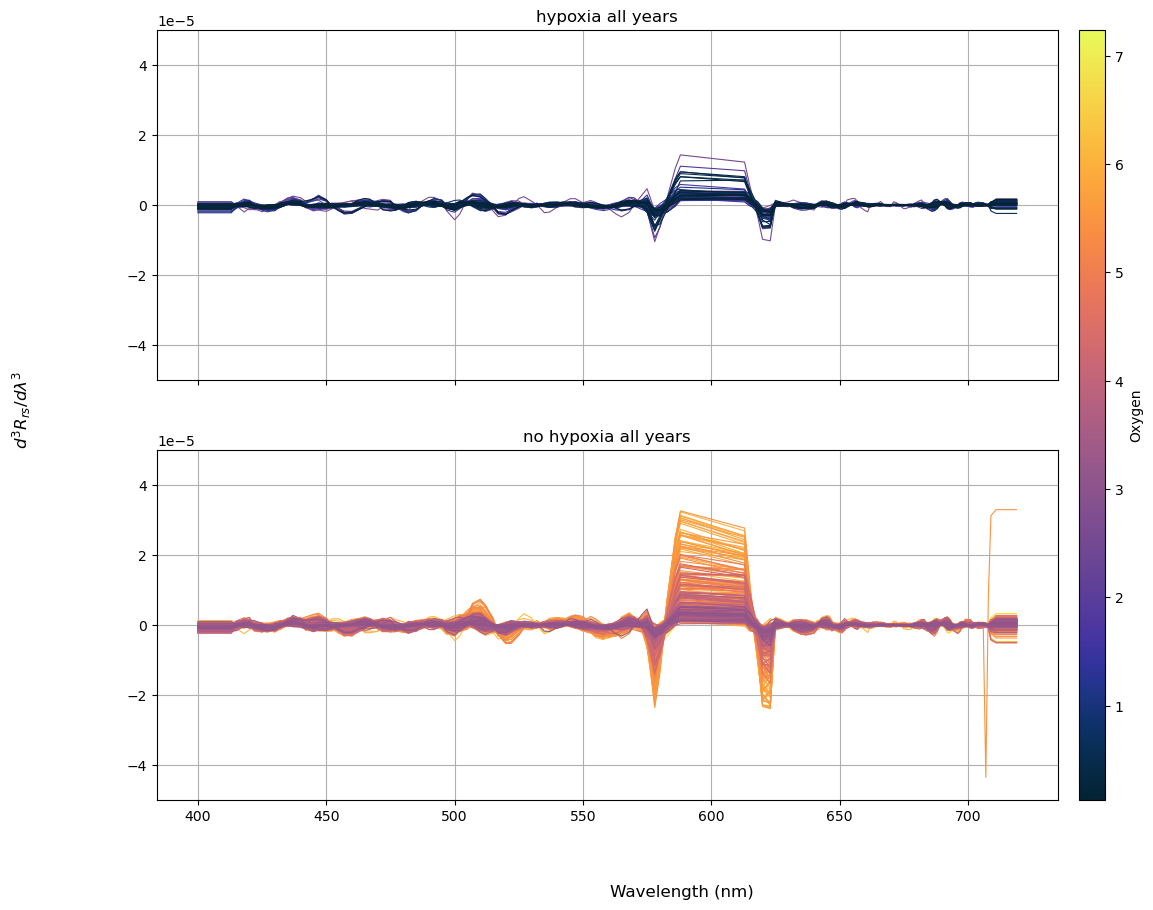

In [40]:
#now seperate into groups
dfs = [df_h,df_nh]
titles = ["hypoxia all years", "no hypoxia all years" ] # Change these titles as needed

window = 11 
polyorder = 3
dlam = np.mean(np.diff(x_vals))

cmap = cmo.thermal
norm = colors.Normalize(vmin=min(sorted_df1['oxygen']), vmax=max(sorted_df1['oxygen'])) #already have
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)
axes_flat = axes.flatten() 
#rrs_sel = df_new[rrs_cols]
ymin, ymax = np.inf, -np.inf


for df, title, ax in zip(dfs, titles, axes_flat):
    sorted_df = df.sort_values(by='oxygen', ascending=False)
    rrs_sel = sorted_df[rrs_cols]
    for spectrum, oxy_val in zip(rrs_sel.values, sorted_df['oxygen'].values):
        # Savitzky–Golay 2nd derivative
        spec_sg2 = savgol_filter(spectrum, window_length=window, polyorder=polyorder, deriv=3, delta=dlam)
        ymin = min(ymin, np.nanmin(spec_sg2))
        ymax = max(ymax, np.nanmax(spec_sg2))
        color = cmap(norm(oxy_val))
        ax.plot(x_vals, spec_sg2, color=color, linewidth=0.8)
    ax.set_title(title)
    #ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
    lim = max(abs(ymin), abs(ymax))
    ax.set_ylim(-0.00005, 0.00005)
    ax.grid(True) 

for ax in axes.flat:
    ax.label_outer()
fig.supxlabel("Wavelength (nm)")
fig.supylabel(r"$d^3 R_{rs} / d\lambda^3$")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02, aspect=30)
cbar.set_label("Oxygen")
plt.show()


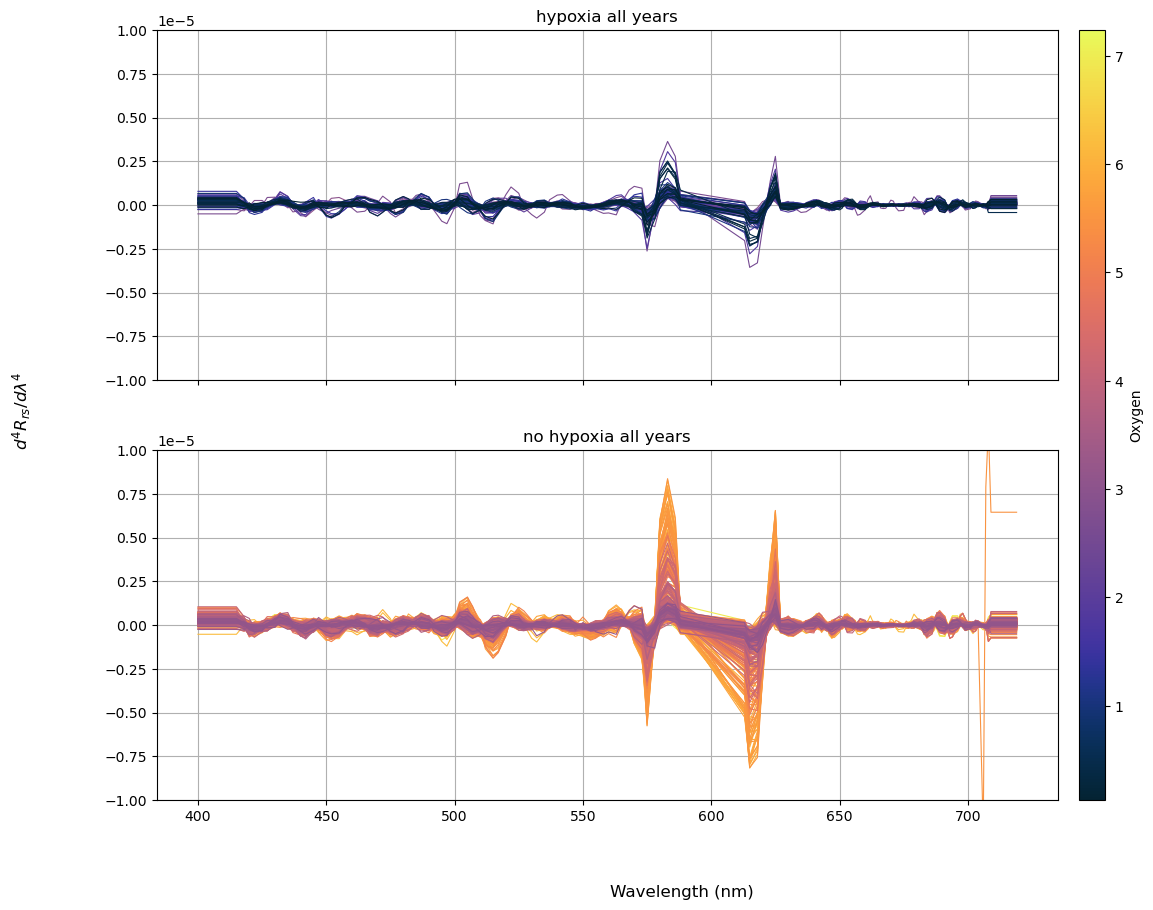

In [41]:
#now seperate into groups
dfs = [df_h,df_nh]
titles = ["hypoxia all years", "no hypoxia all years" ] # Change these titles as needed

window = 13 
polyorder = 4
dlam = np.mean(np.diff(x_vals))

cmap = cmo.thermal
norm = colors.Normalize(vmin=min(df_new['oxygen']), vmax=max(df_new['oxygen'])) #already have
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)
axes_flat = axes.flatten() 
#rrs_sel = df_new[rrs_cols]
ymin, ymax = np.inf, -np.inf


for df, title, ax in zip(dfs, titles, axes_flat):
    sorted_df = df.sort_values(by='oxygen', ascending=False)
    rrs_sel = sorted_df[rrs_cols]
    for spectrum, oxy_val in zip(rrs_sel.values, sorted_df['oxygen'].values):
        # Savitzky–Golay 2nd derivative
        spec_sg2 = savgol_filter(spectrum, window_length=window, polyorder=polyorder, deriv=4, delta=dlam)
        ymin = min(ymin, np.nanmin(spec_sg2))
        ymax = max(ymax, np.nanmax(spec_sg2))
        color = cmap(norm(oxy_val))
        ax.plot(x_vals, spec_sg2, color=color, linewidth=0.8)
    ax.set_title(title)
    #ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
    lim = max(abs(ymin), abs(ymax))
    ax.set_ylim(-0.00001, 0.00001)
    ax.grid(True) 

for ax in axes.flat:
    ax.label_outer()
fig.supxlabel("Wavelength (nm)")
fig.supylabel(r"$d^4 R_{rs} / d\lambda^4$")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02, aspect=30)
cbar.set_label("Oxygen")
plt.show()
